# Modulo de busqueda genetica

In [3]:
from lib.oracle import run_oracle, safe_run_oracle
from lib.explorer import explore_points, explore_points_parallel
from lib.utils import estimate_exploration_time, expand_parameter_space

In [2]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

In [4]:
# m_phi, mA, alpha, beta, lambda6, lambda7, m12
run_oracle([125, 300, 0.1, 2.6, 0.3, 0.2, 0.5])

{'error': 'Invalid parameter set.'}

## Clase personalizada

In [6]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from lib.oracle import run_oracle  # Asegurarse que el oracle está en el path

class OracleProblem(ElementwiseProblem):
    def __init__(self):
        # Definir número de variables (7), objetivos (2) y restricciones (3).
        # Los límites se deben ajustar según el conocimiento del problema.
        super().__init__(
            n_var=7,
            n_obj=2,
            n_constr=3,
            #            m_phi, mA, alpha, beta, lambda6, lambda7, m12
            xl=np.array([125, 100, -1, -1.62, -1, -1, -1]),
            xu=np.array([300, 500, 1, 1.62, 1, 1, 1])
        )
    
    def _evaluate(self, x, out, *args, **kwargs):
        # Convertir x en lista (o en el formato adecuado) para el oracle
        result = run_oracle(x.tolist())
        
        # Si el oracle devuelve un error, se asigna un castigo (penalty) muy alto
        if 'error' in result:
            # Asignamos valores grandes a los objetivos para penalizar al individuo.
            f1 = 1e10
            f2 = 1e10
            # Para las restricciones, indicamos incumplimiento (por ejemplo, valor negativo)
            g1 = -1.0  
            g2 = -1.0
            g3 = -1.0
        else:
            # Si el punto es válido, extraemos los objetivos:
            # Objetivo 1: total_width_h2 (minimizar)
            f1 = result['w_total_h2']
            # Objetivo 2: branching_ratio_h2_gaga (maximizar; por eso usamos el negativo)
            f2 = -result['branching_ratio_h2_gaga']

            # Las restricciones se plantean de modo que se cumplan si son <= 0.
            # Se puede definir por ejemplo: g = 1 - valor_obtenido, de forma que si el valor es 1 (válido), g = 0.
            g1 = 1 - result['positivity_ok']
            g2 = 1 - result['unitarity_ok']
            g3 = 1 - result['perturbativity_ok']

        out["F"] = [f1, f2]
        out["G"] = [g1, g2, g3]


In [14]:
from pymoo.algorithms.moo.nsga2 import NSGA2

# Configurar el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=50  # tamaño de población (ajustable)
)


In [15]:
from pymoo.optimize import minimize

problem = OracleProblem()

res = minimize(
    problem,
    algorithm,
    ('n_gen', 100),  # Número de generaciones, se puede aumentar para mayor exploración
    seed=42,
    verbose=True
)


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       50 |      3 |  0.000000E+00 |  0.8200000000 |             - |             -
     2 |      100 |      1 |  0.000000E+00 |  0.000000E+00 |  0.2325481638 |         ideal
     3 |      150 |      2 |  0.000000E+00 |  0.000000E+00 |  2.2413210937 |         ideal
     4 |      200 |      3 |  0.000000E+00 |  0.000000E+00 |  0.6323708938 |         ideal
     5 |      250 |      1 |  0.000000E+00 |  0.000000E+00 |  0.5120436554 |         ideal
     6 |      300 |      2 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
     7 |      350 |      2 |  0.000000E+00 |  0.000000E+00 |  0.1759409768 |         ideal
     8 |      400 |      4 |  0.000000E+00 |  0.000000E+00 |  0.3613470071 |         ideal
     9 |      450 |      5 |  0.000000E+00 |  0.000000E+00 |  0.0996383297 |         ideal
    10 |      500 |      5 |  0.000000E+00 |  0.000000E+00 |  0.0062938447 |         ideal

### Columnas de la Tabla  
Este log es una forma de “registro en vivo” del desempeño del algoritmo evolutivo a lo largo de su ejecución. Cada columna aporta una pieza de información:
- **Generación y Evaluaciones** muestran la progresión temporal.
- **n_nds** indica cuántas soluciones sobresalen en el frente Pareto.
- **cv_min y cv_avg** indican cómo se están respetando las restricciones.
- **eps e indicator** te permiten apreciar la calidad de la aproximación al frente de soluciones óptimas.


1. **n_gen**  
   - **Significado:** Número de la generación actual.  
   - **Explicación:** En algoritmos evolutivos como NSGA-II, la población evoluciona generación tras generación. Aquí, "n_gen" indica en qué iteración (o generación) se encuentra el algoritmo.  
   - **Ejemplo:** En la primera línea “n_gen = 1”, es la primera generación.

2. **n_eval**  
   - **Significado:** Número total de evaluaciones realizadas.  
   - **Explicación:** Cada vez que el algoritmo evalúa una solución (por ejemplo, se llama al oracle), se incrementa este contador. Es útil para conocer el coste computacional global de la búsqueda.  
   - **Ejemplo:** “n_eval = 20” indica que se han hecho 20 evaluaciones en total hasta ese punto.

3. **n_nds**  
   - **Significado:** Número de soluciones no dominadas (o tamaño de la frontera de Pareto) en la población actual.  
   - **Explicación:** En optimización multiobjetivo, las soluciones no dominadas son aquellas que no son "peor" que otra solución en todos los objetivos. Este número te da una idea del tamaño del frente Pareto actual.  
   - **Ejemplo:** “n_nds = 1” significa que, en esa generación, hay una solución que destaca como la no dominada.

4. **cv_min**  
   - **Significado:** Valor mínimo de violación de restricciones dentro de la población.  
   - **Explicación:** Cuando se trabaja con restricciones (por ejemplo, las condiciones de validez en tu problema), se mide cuánto incumple cada solución.  
     - Un valor de `0.0` indica que al menos una solución cumple todas las restricciones.  
     - Si hubiera valores mayores que cero, significaría que la peor violación entre las soluciones es positiva (es decir, hay soluciones que incumplen alguna restricción).  
   - **Ejemplo:** “cv_min = 0.000000E+00” indica que hay soluciones factibles en la población.

5. **cv_avg**  
   - **Significado:** Promedio de violación de restricciones en toda la población.  
   - **Explicación:** Este valor da una idea general de cuán “viable” es la población. En una población en la que todas las soluciones son factibles, este valor debería ser 0.  
   - **Ejemplo:** En la primera generación se observa “cv_avg = 0.7500000000”, lo que indica que, en promedio, la población tiene cierta violación de las restricciones, pero en generaciones posteriores se reduce a 0 cuando se encuentran soluciones factibles.

6. **eps**  
   - **Significado:** Valor relacionado con algún indicador de calidad, a menudo el **ε-indicator**.  
   - **Explicación:**  
     - El ε-indicator es una medida que cuantifica qué tan cerca está la aproximación actual del frente Pareto de la solución ideal.  
     - Por ejemplo, un valor mayor indica que las soluciones están "más lejos" del ideal, mientras que un valor cercano a 0 indicaría una mejor aproximación.  
   - **Ejemplo:** “eps = 1.9620742200” en la segunda generación y “eps = 0.000000E+00” en otra, reflejando distintos escenarios de convergencia.

7. **indicator**  
   - **Significado:** Etiqueta o descriptor asociado al valor de calidad mostrado.  
   - **Explicación:**  
     - Esta columna suele indicar de qué referencia se está hablando (por ejemplo, “ideal”, “nadir” u otros marcadores que indica el algoritmo para ayudar a interpretar el valor de `eps`).  
     - “ideal” normalmente se relaciona con el punto ideal (el mejor valor teórico en cada objetivo), y “nadir” al punto nadir (los peores de los no dominados).  
     - Otros marcadores (como “f”) podrían indicar otras condiciones, por ejemplo, que se ha detectado que la población es factible o que se han alcanzado ciertos umbrales.  
   - **Ejemplo:** En algunas generaciones se indica “ideal” o “nadir”, lo que ayuda a identificar qué referencia se utiliza para evaluar el progreso.

---

### Lectura y Utilidad del Log

- **Evolución de la población:**  
  Cada fila representa el estado del algoritmo en una generación. Puedes seguir cómo mejora la viabilidad (reducción en el promedio de violaciones de restricciones) y la calidad del frente Pareto (medido con el indicador ε).

- **Factibilidad:**  
  Si en algún momento el `cv_min` o `cv_avg` dejan de ser mayores a 0, es una señal de que el algoritmo está encontrando soluciones que cumplen todas las restricciones.

- **Indicadores de convergencia:**  
  Los valores del ε-indicator y su descriptor (“ideal” o “nadir”) permiten evaluar si la población se está acercando al frente Pareto deseado. Estos indicadores se utilizan para entender la convergencia y la diversidad de las soluciones.

- **Número de Evaluaciones (n_eval):**  
  Permite tener una idea del esfuerzo computacional y, en combinación con el número de generaciones (`n_gen`), se puede ajustar parámetros como el tamaño de la población y el número de generaciones para equilibrar coste y calidad de la solución.




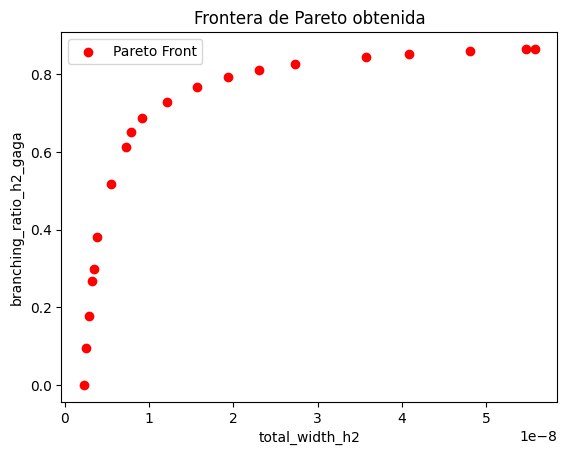

In [10]:
import matplotlib.pyplot as plt

# Extraer los objetivos de las soluciones viables
F = res.F

plt.scatter(F[:, 0], -F[:, 1], c="red", label="Pareto Front")  
plt.xlabel("total_width_h2")
plt.ylabel("branching_ratio_h2_gaga")
plt.title("Frontera de Pareto obtenida")
plt.legend()
plt.show()


In [16]:
import pandas as pd

# Construir DataFrame de las variables de decisión
df_decision = pd.DataFrame(res.X, columns=["m_phi", "mA", "alpha", "beta", "lambda6", "lambda7", "m12"])

# Construir DataFrame de los objetivos:
# Como durante la evaluación se transformó el branching_ratio_h2_gaga a f2 = -branching_ratio_h2_gaga,
# revertimos el signo para recuperarlo.
df_obj = pd.DataFrame({
    "total_width_h2": res.F[:, 0],
    "branching_ratio_h2_gaga": -res.F[:, 1]
})

# Concatenar ambos DataFrames para tener las soluciones Pareto completas
pareto_solutions = pd.concat([df_decision, df_obj], axis=1)

# Mostrar un resumen de las soluciones
print("Soluciones Pareto:")
print(pareto_solutions.head())


Soluciones Pareto:
        m_phi          mA     alpha      beta   lambda6   lambda7       m12  \
0  125.003936  432.924718 -0.803593  0.767176  0.039729  0.066058 -0.817163   
1  125.000224  379.236952 -0.803593  0.767175 -0.964463 -0.030380 -0.813279   
2  125.000008  395.691342 -0.803593  0.767176 -0.926622 -0.001548 -0.636271   
3  125.000008  396.226309 -0.803593  0.767176 -0.917455  0.005176 -0.636271   
4  125.000043  409.002128 -0.803593  0.767176 -0.920055 -0.002228 -0.761007   

   total_width_h2  branching_ratio_h2_gaga  
0    7.489765e-13                 0.000133  
1    1.084929e-09                 0.913123  
2    8.908133e-10                 0.913109  
3    8.802243e-10                 0.913105  
4    7.663069e-10                 0.913077  


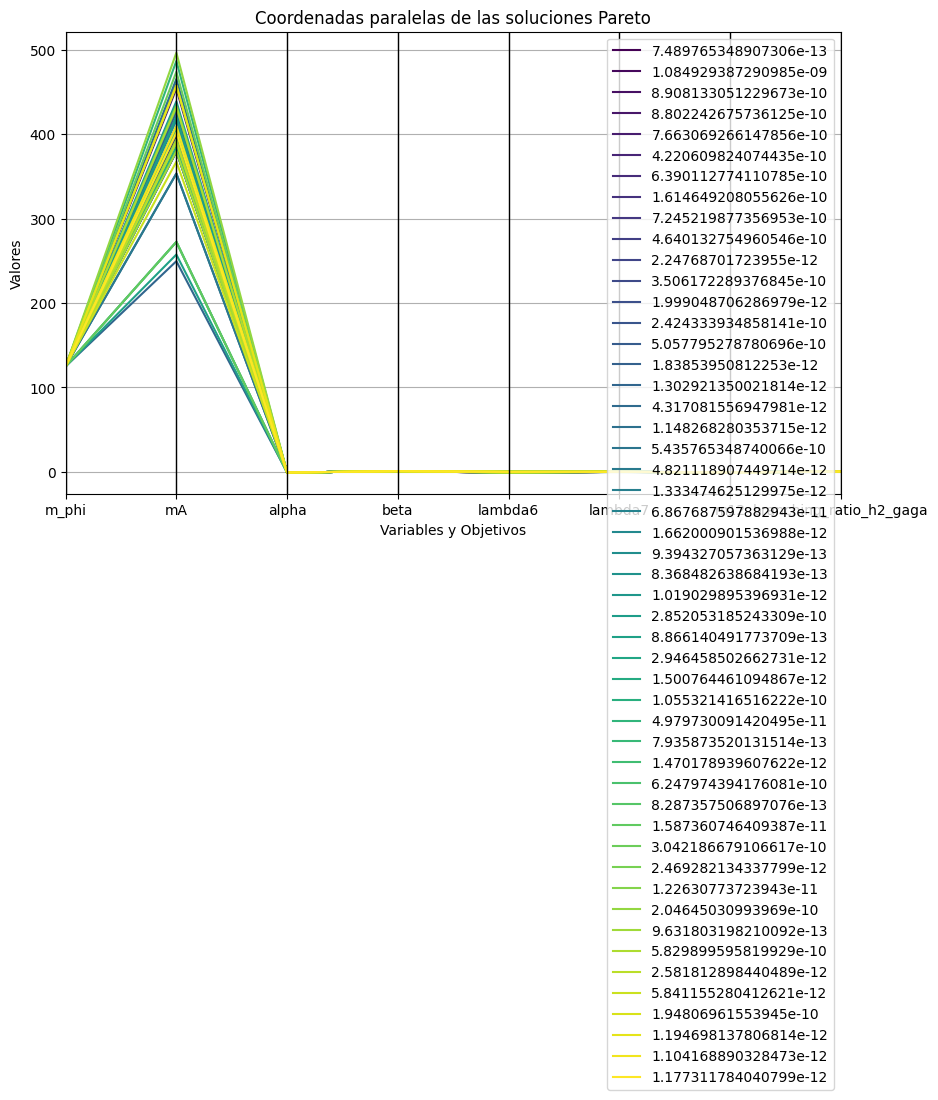

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(pareto_solutions, class_column="total_width_h2", colormap="viridis")
plt.title("Coordenadas paralelas de las soluciones Pareto")
plt.xlabel("Variables y Objetivos")
plt.ylabel("Valores")
plt.show()


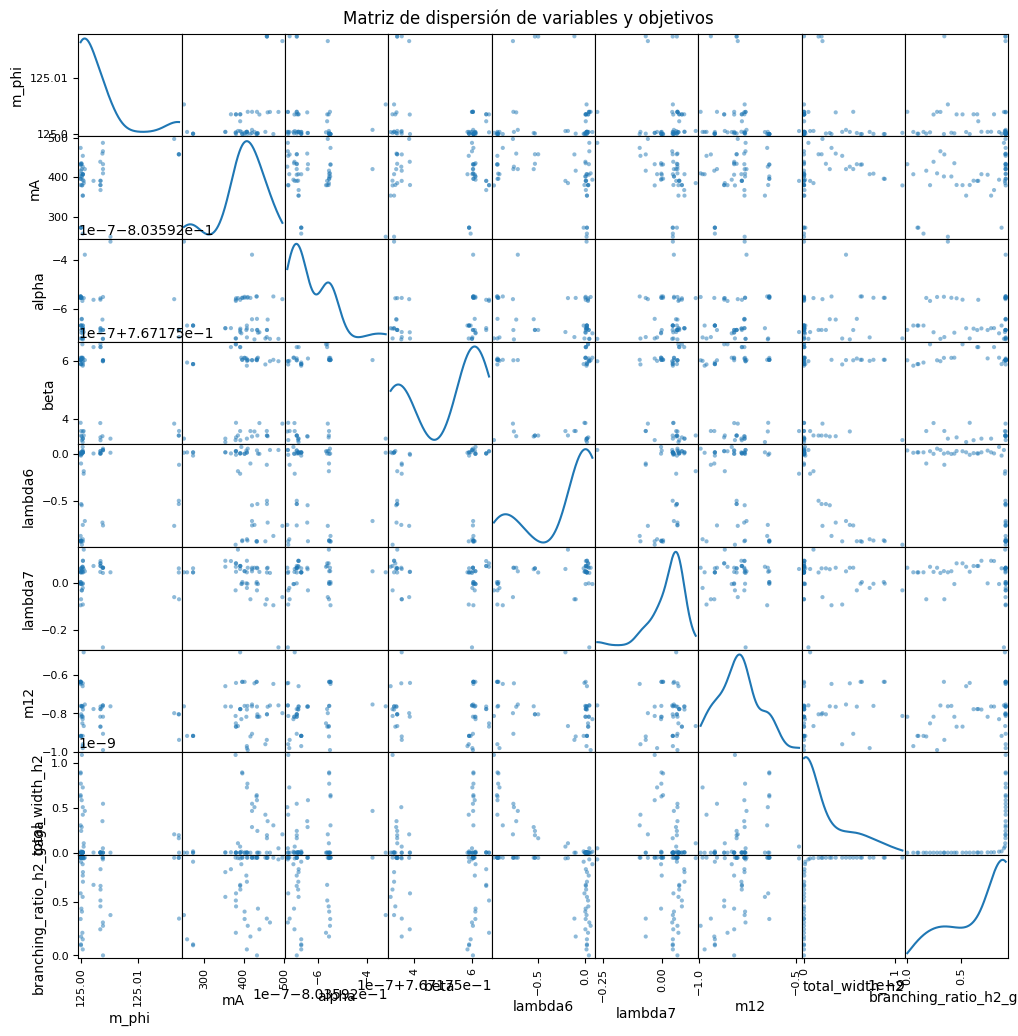

In [18]:
pd.plotting.scatter_matrix(pareto_solutions, figsize=(12, 12), diagonal="kde")
plt.suptitle("Matriz de dispersión de variables y objetivos", y=0.9)
plt.show()


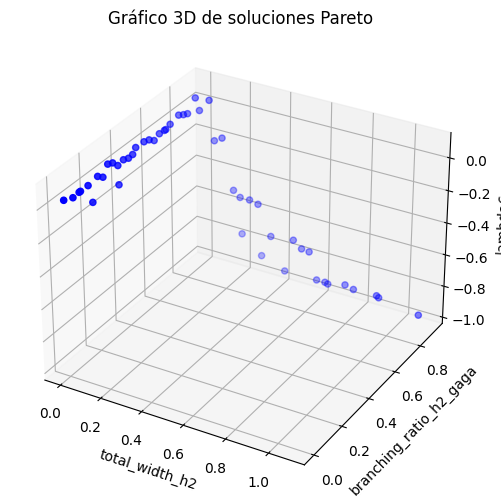

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # Importación necesaria para graficar en 3D

third_variable = ["m_phi", "mA", "alpha", "beta", "lambda6", "lambda7", "m12"][4]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    pareto_solutions["total_width_h2"], 
    pareto_solutions["branching_ratio_h2_gaga"],
    pareto_solutions[third_variable],
    c="blue", marker="o"
)
ax.set_xlabel("total_width_h2")
ax.set_ylabel("branching_ratio_h2_gaga")
ax.set_zlabel(third_variable)
plt.title("Gráfico 3D de soluciones Pareto")
plt.show()


In [20]:
from pymoo.optimize import minimize

res = minimize(
    problem,
    algorithm,
    ("n_gen", 100),
    seed=42,
    verbose=True,
    save_history=True  # Guarda el historial de generaciones
)


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |       50 |      3 |  0.000000E+00 |  0.8200000000 |             - |             -
     2 |      100 |      1 |  0.000000E+00 |  0.000000E+00 |  0.2325481638 |         ideal
     3 |      150 |      2 |  0.000000E+00 |  0.000000E+00 |  2.2413210937 |         ideal
     4 |      200 |      3 |  0.000000E+00 |  0.000000E+00 |  0.6323708938 |         ideal
     5 |      250 |      1 |  0.000000E+00 |  0.000000E+00 |  0.5120436554 |         ideal
     6 |      300 |      2 |  0.000000E+00 |  0.000000E+00 |  1.0000000000 |         ideal
     7 |      350 |      2 |  0.000000E+00 |  0.000000E+00 |  0.1759409768 |         ideal
     8 |      400 |      4 |  0.000000E+00 |  0.000000E+00 |  0.3613470071 |         ideal
     9 |      450 |      5 |  0.000000E+00 |  0.000000E+00 |  0.0996383297 |         ideal
    10 |      500 |      5 |  0.000000E+00 |  0.000000E+00 |  0.0062938447 |         ideal

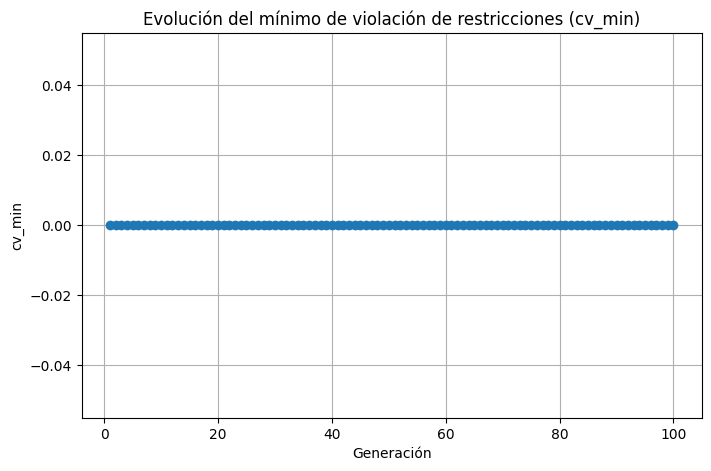

In [21]:
# Ejemplo: extraer el número de evaluaciones y el mínimo de violación de restricciones (cv_min) por generación.
generations = []
cv_mins = []

for algo in res.history:
    generations.append(algo.n_gen)
    # Aquí se asume que puedes extraer el valor 'cv_min' del registro (esto dependerá de cómo esté configurada tu función de evaluación o callback)
    # Por ejemplo, si cada instancia 'algo' tiene un atributo 'pop' con soluciones, podrías calcular el mínimo de las violaciones.
    # En este ejemplo se usa un valor simulado.
    cv_mins.append(0)  # Si tus soluciones son factibles, cv_min = 0

plt.figure(figsize=(8, 5))
plt.plot(generations, cv_mins, marker="o")
plt.title("Evolución del mínimo de violación de restricciones (cv_min)")
plt.xlabel("Generación")
plt.ylabel("cv_min")
plt.grid(True)
plt.show()
